In [1]:
import pandas as pd
import numpy as np
import shap
import warnings

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

from imblearn.over_sampling import SMOTE

In [2]:
data = pd.read_csv(
    r"C:\Users\Haarun\obesity_project\data\Obesity_Dataset.tsv",
    sep="\t"
)

print(data.head())
print(data.shape)

  DATE ADDED TO CATALOG  PUBMEDID FIRST AUTHOR        DATE            JOURNAL  \
0            2018-11-05  30120429  Schlauch KA  2018-08-17  Int J Obes (Lond)   
1            2018-11-05  30120429  Schlauch KA  2018-08-17  Int J Obes (Lond)   
2            2018-11-05  30120429  Schlauch KA  2018-08-17  Int J Obes (Lond)   
3            2018-11-05  30120429  Schlauch KA  2018-08-17  Int J Obes (Lond)   
4            2018-11-05  30120429  Schlauch KA  2018-08-17  Int J Obes (Lond)   

                                   LINK  \
0  www.ncbi.nlm.nih.gov/pubmed/30120429   
1  www.ncbi.nlm.nih.gov/pubmed/30120429   
2  www.ncbi.nlm.nih.gov/pubmed/30120429   
3  www.ncbi.nlm.nih.gov/pubmed/30120429   
4  www.ncbi.nlm.nih.gov/pubmed/30120429   

                                               STUDY  \
0  Single-nucleotide polymorphisms in a cohort of...   
1  Single-nucleotide polymorphisms in a cohort of...   
2  Single-nucleotide polymorphisms in a cohort of...   
3  Single-nucleotide polymorph

In [3]:
data["Target"] = data["P-VALUE"].apply(
    lambda x: 1 if x < 1e-6 else 0
)

print(data["Target"].value_counts())

Target
1    1426
0     115
Name: count, dtype: int64


In [4]:
features = [
    "CHR_ID",
    "CHR_POS",
    "REPORTED GENE(S)",
    "MAPPED_GENE",
    "RISK ALLELE FREQUENCY",
    "OR or BETA",
    "STRONGEST SNP-RISK ALLELE",
    "SNPS",
    "CONTEXT",
    "INTERGENIC",
    "UPSTREAM_GENE_DISTANCE",
    "DOWNSTREAM_GENE_DISTANCE"
]

X = data[features].copy()
y = data["Target"]

In [5]:
X = X.fillna("Unknown")

In [6]:
categorical_columns = [
    "REPORTED GENE(S)",
    "MAPPED_GENE",
    "STRONGEST SNP-RISK ALLELE",
    "SNPS",
    "CONTEXT",
    "INTERGENIC"
]

label_encoders = {}

for col in categorical_columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

In [7]:
numeric_columns = [
    "CHR_ID",
    "CHR_POS",
    "RISK ALLELE FREQUENCY",
    "OR or BETA",
    "UPSTREAM_GENE_DISTANCE",
    "DOWNSTREAM_GENE_DISTANCE"
]

for col in numeric_columns:
    X[col] = pd.to_numeric(X[col], errors="coerce")

X = X.fillna(0)

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print(y_train_smote.value_counts())

Target
1    1140
0    1140
Name: count, dtype: int64


In [11]:
optimized_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    learning_rate="adaptive",
    max_iter=1000,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

optimized_mlp.fit(X_train_smote, y_train_smote)

,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'adaptive'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


In [12]:
optimized_mlp.fit(
    X_train_smote,
    y_train_smote
)

,hidden_layer_sizes,"(128, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'adaptive'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


In [13]:
y_pred_opt = optimized_mlp.predict(X_test)

y_prob_opt = optimized_mlp.predict_proba(X_test)[:, 1]

In [14]:
print("===== OPTIMIZED MLP RESULTS =====")

print("Accuracy:", accuracy_score(y_test, y_pred_opt))

print(classification_report(y_test, y_pred_opt))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_opt))

===== OPTIMIZED MLP RESULTS =====
Accuracy: 0.8673139158576052
              precision    recall  f1-score   support

           0       0.25      0.39      0.31        23
           1       0.95      0.91      0.93       286

    accuracy                           0.87       309
   macro avg       0.60      0.65      0.62       309
weighted avg       0.90      0.87      0.88       309

ROC-AUC: 0.8663727576771054


In [15]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier
from scipy.stats import uniform

In [16]:
param_grid = {
    "hidden_layer_sizes": [
        (64, 32),
        (128, 64),
        (128, 64, 32),
        (256, 128, 64)
    ],
    "activation": ["relu", "tanh"],
    "solver": ["adam"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate": ["constant", "adaptive"],
    "learning_rate_init": [0.001, 0.0005, 0.0001],
    "batch_size": [16, 32, 64],
    "max_iter": [700, 1000]
}

In [17]:
base_mlp = MLPClassifier(
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

In [18]:
mlp_search = RandomizedSearchCV(
    estimator=base_mlp,
    param_distributions=param_grid,
    n_iter=20,
    scoring="roc_auc",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

mlp_search.fit(X_train_smote, y_train_smote)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,MLPClassifier...ndom_state=42)
,param_distributions,"{'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.001, ...], 'batch_size': [16, 32, ...], 'hidden_layer_sizes': [(64, ...), (128, ...), ...], ...}"
,n_iter,20
,scoring,'roc_auc'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [19]:
print("Best Parameters:")
print(mlp_search.best_params_)

print("Best CV ROC-AUC:")
print(mlp_search.best_score_)

Best Parameters:
{'solver': 'adam', 'max_iter': 1000, 'learning_rate_init': 0.001, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (128, 64), 'batch_size': 32, 'alpha': 0.0001, 'activation': 'relu'}
Best CV ROC-AUC:
0.9805863342566944


In [20]:
fine_tuned_mlp = mlp_search.best_estimator_

y_pred_ft = fine_tuned_mlp.predict(X_test)
y_prob_ft = fine_tuned_mlp.predict_proba(X_test)[:, 1]

print("===== FINE-TUNED MLP RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred_ft))
print(classification_report(y_test, y_pred_ft))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_ft))

===== FINE-TUNED MLP RESULTS =====
Accuracy: 0.8673139158576052
              precision    recall  f1-score   support

           0       0.28      0.48      0.35        23
           1       0.96      0.90      0.93       286

    accuracy                           0.87       309
   macro avg       0.62      0.69      0.64       309
weighted avg       0.90      0.87      0.88       309

ROC-AUC: 0.8660687138948009


In [21]:
import pickle
import os

MODEL_DIR = r"C:\Users\Haarun\obesity_project\models"
os.makedirs(MODEL_DIR, exist_ok=True)

with open(os.path.join(MODEL_DIR, "fine_tuned_mlp.pkl"), "wb") as f:
    pickle.dump(fine_tuned_mlp, f)

print("Fine-tuned MLP saved successfully.")

Fine-tuned MLP saved successfully.


In [22]:
comparison = pd.DataFrame({
    "Model": ["Optimized MLP", "Fine-Tuned MLP"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_opt),
        accuracy_score(y_test, y_pred_ft)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, y_prob_opt),
        roc_auc_score(y_test, y_prob_ft)
    ]
})

comparison

,Model,Accuracy,ROC_AUC
0,Optimized MLP,0.867314,0.866373
1,Fine-Tuned MLP,0.867314,0.866069


In [23]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neural_network import MLPClassifier

targeted_params = {
    "hidden_layer_sizes": [
        (64, 32),
        (96, 48),
        (128, 64),
        (128, 64, 32),
        (96, 64, 32)
    ],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.0005, 0.001, 0.005],
    "learning_rate": ["adaptive"],
    "learning_rate_init": [0.001, 0.0007, 0.0005],
    "batch_size": [16, 32, 64],
    "max_iter": [1000],
    "early_stopping": [True],
    "validation_fraction": [0.15, 0.2]
}

base_mlp = MLPClassifier(
    solver="adam",
    random_state=42
)

targeted_search = RandomizedSearchCV(
    estimator=base_mlp,
    param_distributions=targeted_params,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

targeted_search.fit(X_train_smote, y_train_smote)

print("Best Parameters:")
print(targeted_search.best_params_)

print("Best CV ROC-AUC:")
print(targeted_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters:
{'validation_fraction': 0.15, 'max_iter': 1000, 'learning_rate_init': 0.0005, 'learning_rate': 'adaptive', 'hidden_layer_sizes': (96, 64, 32), 'early_stopping': True, 'batch_size': 16, 'alpha': 0.0005, 'activation': 'tanh'}
Best CV ROC-AUC:
0.9823638042474606


In [24]:
targeted_mlp = targeted_search.best_estimator_

y_pred_targeted = targeted_mlp.predict(X_test)
y_prob_targeted = targeted_mlp.predict_proba(X_test)[:, 1]

print("===== TARGETED FINE-TUNED MLP RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred_targeted))
print(classification_report(y_test, y_pred_targeted))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_targeted))

===== TARGETED FINE-TUNED MLP RESULTS =====
Accuracy: 0.8478964401294499
              precision    recall  f1-score   support

           0       0.27      0.61      0.37        23
           1       0.96      0.87      0.91       286

    accuracy                           0.85       309
   macro avg       0.62      0.74      0.64       309
weighted avg       0.91      0.85      0.87       309

ROC-AUC: 0.8791425965339008


In [26]:
from xgboost import XGBClassifier

In [28]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_smote, y_train_smote)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [29]:
y_pred_xgb = xgb.predict(X_test)

y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

In [30]:
print("===== XGBOOST RESULTS =====")

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

print(classification_report(y_test, y_pred_xgb))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

===== XGBOOST RESULTS =====
Accuracy: 0.889967637540453
              precision    recall  f1-score   support

           0       0.38      0.74      0.50        23
           1       0.98      0.90      0.94       286

    accuracy                           0.89       309
   macro avg       0.68      0.82      0.72       309
weighted avg       0.93      0.89      0.91       309

ROC-AUC: 0.9302219519610824


In [31]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# probabilities from optimized MLP
mlp_prob = optimized_mlp.predict_proba(X_test)[:, 1]

# probabilities from XGBoost
xgb_prob = xgb.predict_proba(X_test)[:, 1]

# average probability
ensemble_prob = (mlp_prob + xgb_prob) / 2

# convert probability to class
ensemble_pred = (ensemble_prob >= 0.5).astype(int)

print("===== HYBRID ENSEMBLE RESULTS =====")
print("Accuracy:", accuracy_score(y_test, ensemble_pred))
print(classification_report(y_test, ensemble_pred))
print("ROC-AUC:", roc_auc_score(y_test, ensemble_prob))

===== HYBRID ENSEMBLE RESULTS =====
Accuracy: 0.8802588996763754
              precision    recall  f1-score   support

           0       0.31      0.48      0.37        23
           1       0.96      0.91      0.93       286

    accuracy                           0.88       309
   macro avg       0.63      0.70      0.65       309
weighted avg       0.91      0.88      0.89       309

ROC-AUC: 0.9139556096077835


In [32]:
ensemble_prob_weighted = (0.4 * mlp_prob) + (0.6 * xgb_prob)

ensemble_pred_weighted = (ensemble_prob_weighted >= 0.5).astype(int)

print("===== WEIGHTED HYBRID ENSEMBLE RESULTS =====")
print("Accuracy:", accuracy_score(y_test, ensemble_pred_weighted))
print(classification_report(y_test, ensemble_pred_weighted))
print("ROC-AUC:", roc_auc_score(y_test, ensemble_prob_weighted))

===== WEIGHTED HYBRID ENSEMBLE RESULTS =====
Accuracy: 0.9029126213592233
              precision    recall  f1-score   support

           0       0.41      0.65      0.50        23
           1       0.97      0.92      0.95       286

    accuracy                           0.90       309
   macro avg       0.69      0.79      0.72       309
weighted avg       0.93      0.90      0.91       309

ROC-AUC: 0.9191243539069626


In [34]:
from xgboost import XGBClassifier

xgb_fixed = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss",
    base_score=0.5
)

xgb_fixed.fit(X_train_smote, y_train_smote)

,objective,'binary:logistic'
,base_score,0.5
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


PermutationExplainer explainer: 51it [00:14,  3.38it/s]                                                                


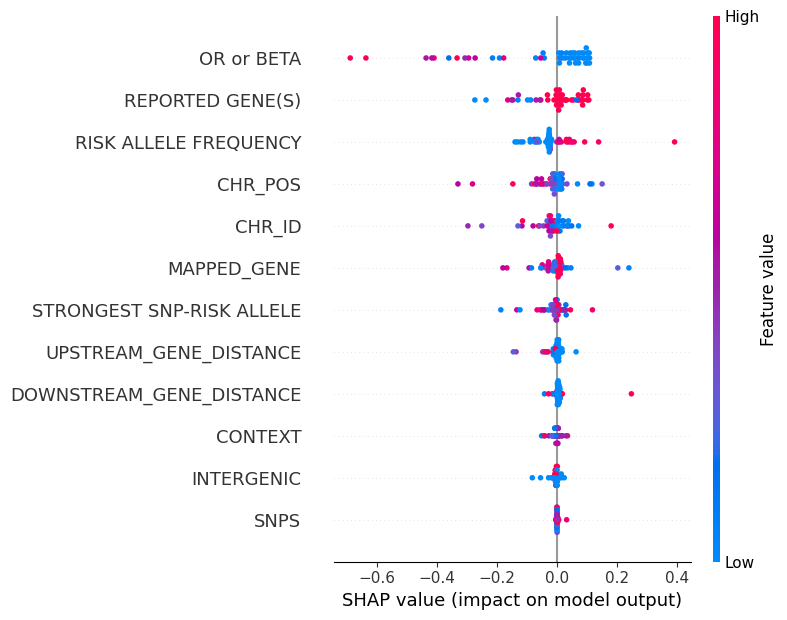

In [36]:
explainer_final = shap.Explainer(
    xgb_fixed.predict,
    X_train_smote[:100]
)

shap_values_final = explainer_final(X_test[:50])

shap.summary_plot(
    shap_values_final,
    X_test[:50],
    feature_names=features
)

In [37]:
import pickle
import os

MODEL_DIR = r"C:\Users\Haarun\obesity_project\models"
os.makedirs(MODEL_DIR, exist_ok=True)

with open(os.path.join(MODEL_DIR, "optimized_mlp.pkl"), "wb") as f:
    pickle.dump(optimized_mlp, f)

with open(os.path.join(MODEL_DIR, "xgb_fixed.pkl"), "wb") as f:
    pickle.dump(xgb_fixed, f)

with open(os.path.join(MODEL_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)

with open(os.path.join(MODEL_DIR, "label_encoders.pkl"), "wb") as f:
    pickle.dump(label_encoders, f)

with open(os.path.join(MODEL_DIR, "features.pkl"), "wb") as f:
    pickle.dump(features, f)

print("Final model files saved successfully.")

Final model files saved successfully.


In [38]:
final_results = pd.DataFrame({
    "Model": [
        "MLP",
        "Optimized MLP",
        "Fine-Tuned MLP",
        "XGBoost",
        "Hybrid Ensemble"
    ],
    "Accuracy": [
        0.9093,
        accuracy_score(y_test, y_pred_opt),
        accuracy_score(y_test, y_pred_ft),
        0.9029,
        accuracy_score(y_test, ensemble_pred_weighted)
    ],
    "ROC_AUC": [
        0.8700,
        roc_auc_score(y_test, y_prob_opt),
        roc_auc_score(y_test, y_prob_ft),
        0.9309,
        roc_auc_score(y_test, ensemble_prob_weighted)
    ]
})

final_results.to_csv(
    r"C:\Users\Haarun\obesity_project\results\final_model_results.csv",
    index=False
)

final_results

,Model,Accuracy,ROC_AUC
0,MLP,0.909300,0.870000
1,Optimized MLP,0.867314,0.866373
2,Fine-Tuned MLP,0.867314,0.866069
3,XGBoost,0.902900,0.930900
4,Hybrid Ensemble,0.902913,0.919124
